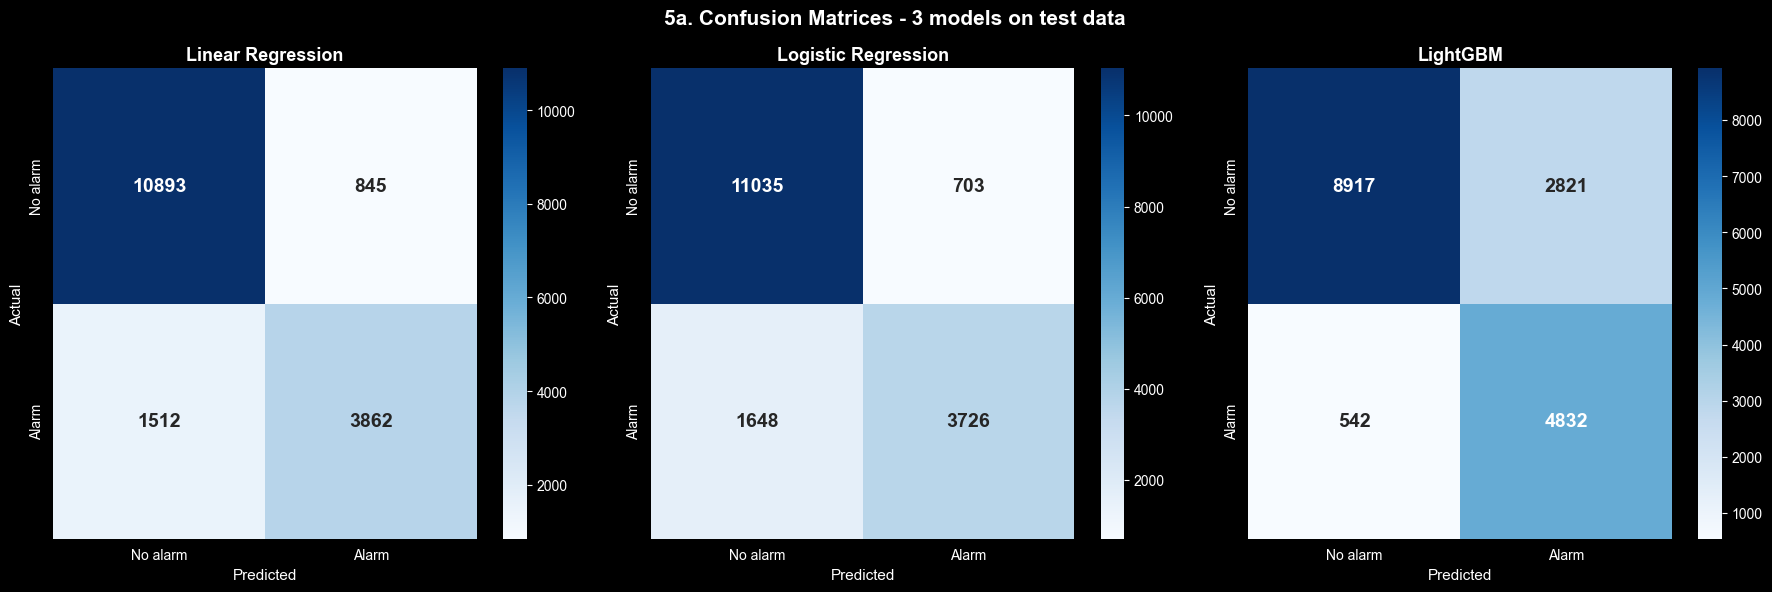

                     Accuracy  Precision  Recall     F1
Model                                                  
Linear Regression       0.862      0.820   0.719  0.766
Logistic Regression     0.863      0.841   0.693  0.760
LightGBM                0.803      0.631   0.899  0.742


In [5]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    f1_score, recall_score, precision_score
)

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

tfidf_cols = [c for c in X_test.columns if c.startswith('tfidf_')]
X_test_no_tfidf = X_test.drop(columns=tfidf_cols)

models = {
    'Linear Regression':   (pickle.load(open('../models/linear_regression.pkl', 'rb')), X_test),
    'Logistic Regression': (pickle.load(open('../models/logistic_regression.pkl', 'rb')), X_test_no_tfidf),
    'LightGBM':            (pickle.load(open('../models/lightgbm_model.pkl', 'rb')), X_test),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_rows = []

for ax, (name, (model, X)) in zip(axes, models.items()):
    y_pred = model.predict(X)
    if y_pred.dtype == float:
        y_pred = (y_pred > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', ax = ax,
                xticklabels = ['No alarm', 'Alarm'],
                yticklabels = ['No alarm', 'Alarm'],
                annot_kws = {'size': 14, 'weight': 'bold'})
    ax.set_title(name, fontsize = 13, fontweight = 'bold')
    ax.set_xlabel('Predicted', fontsize = 11)
    ax.set_ylabel('Actual', fontsize = 11)

    metrics_rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division = 0),
        'Recall':    recall_score(y_test, y_pred, zero_division = 0),
        'F1':        f1_score(y_test, y_pred, zero_division = 0),
    })

plt.suptitle('5a. Confusion Matrices - 3 models on test data',
             fontsize = 15, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../analysis/plots/models/confusion_matrices.png', dpi = 150, bbox_inches = 'tight')
plt.show()

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').round(3)
print(metrics_df)

In [6]:
print("\nFalse negatives (missed alarms) per model:")
for name, (model, X) in models.items():
    y_pred = model.predict(X)
    if y_pred.dtype == float:
        y_pred = (y_pred > 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    fn = cm[1][0]
    print(f"{name}: {fn}")


False negatives (missed alarms) per model:
Linear Regression: 1512
Logistic Regression: 1648
LightGBM: 542


## MAIN CONCLUSION 5A
* **Accuracy** - the proportion of all predictions that were correct. Calculated as (TP + TN) / total. This metric is quite misleading under class imbalance - a model that always predicts no alarm would achieve ~79.3% accuracy on this dataset without detecting a single real threat.
* **Precision** - the proportion of positive predictions that were actually correct. Calculated as TP / (TP + FP). A high precision means the model produces few false alarms.
* **Recall (Sensitivity)** - the proportion of actual positive cases that the model successfully detected. Calculated as TP / (TP + FN). A high recall means the model misses few real threats. This is the primary metric for this task - a missed alarm means civilians have no time to reach shelter, making False Negatives the most critical error type.
* **F1-Score** - the harmonic mean of precision and recall, calculated as 2 * (Precision * Recall) / (Precision + Recall). It provides a single balanced measure that penalizes models which sacrifice one metric for the other. Used as the main evaluation metric throughout this project due to the class imbalance in the dataset.

## Linear Regression
* Accuracy 0.862 - correctly classified 86.2% of all hours. Misleading due to class imbalance, a baseline classifier would achieve ~79.3% by always predicting no alarm.
* Precision 0.82 - of all hours predicted as alarm, 82% were genuine. 18% were false alarms.
* Recall 0.719 - detected 71.9% of real alarms, missing 28.1%. FN = 1512.
* F1 0.766 - balanced score reflecting both missed alarms and false positives.
## Logistic Regression
* Accuracy 0.863 - nearly identical to Linear Regression, but a weaker Recall.
* Precision 0.841 - highest Precision of all three models. Only 15.9% of predicted alarms were false.
* Recall 0.693 - weakest Recall overall, missing 30.7% of real alarms. FN = 1648 - the highest false negative count.
* F1 0.76 - lower than Linear Regression despite better Precision, because Recall drags the score down.
## LightGBM
* Accuracy 0.803 - lowest of the three, but accuracy is not the relevant metric here.
* Precision 0.631 - produces more false alarms than the other models. 36.9% of predicted alarms were incorrect.
* Recall 0.899 - detected 89.9% of real alarms, missing only 10.1%. FN = 542 - the lowest false negative count.
* F1 0.742 - lower than Linear and Logistic Regression in F1, but leads on the task-critical metric of Recall.

## Overall
LightGBM is the most suitable model for air alarm prediction. Despite lower Accuracy and Precision, it minimizes missed alarms (FN = 542 vs 1512 and 1648), which is the highest-priority outcome for a civilian warning system.